In [ ]:
# CTC SCAAML data cleaned-up experiments

# We first load the U-Net trained in ctc_scaaml_data_train.ipynb and the CM1 test data as well as the complex systems
# simulation library and test the trained U-Net on CM1 test and corrupted versions of it.

# Then we load the test datasets for the CM3 implementations to show cross-implementation transfer.

# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2


In [2]:
# Load various potentially useful libraries

import model_library as ml

import numpy as np

from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import model_from_json, Model

from keras import backend as K

from matplotlib import pyplot as plt

from tqdm import tqdm

from experiments import train_unet_ctc

from complex_system_simulation import augment_trace

2026-02-10 23:50:47.520410: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-10 23:50:47.580038: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aron/.pyenv/versions/3.10.12/envs/testenv_kiska/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at le

In [ ]:
import numpy as np
from processing import resize_data

# TODO: The CM1 dataset is not included in this repository.
# You must obtain the CM1 data yourself, downsample it to the target size
# using processing.resize_data, and update the path below accordingly.
CM1_DATA_DIR = '../data/cm1'  # <-- update this path to point to your CM1 data

# Load the CM1 data
# We assume here that it is available at resolution 50000, but any resolution >= 5000 is more or less fine.
data = np.load(f'{CM1_DATA_DIR}/Test_all_50000.npz')
data2 = np.load(f'{CM1_DATA_DIR}/Hold_all_50000.npz')

# Extract X and Y from the data
X, Y = data['X'], data['Y']
Xh, Yh = data2['X'], data2['Y']

# Downsample each trace to 5000 points
X_downsampled = resize_data(X, 5000)
Xh_downsampled = resize_data(Xh, 5000)

100%|██████████| 5648/5648 [00:01<00:00, 4750.60it/s]


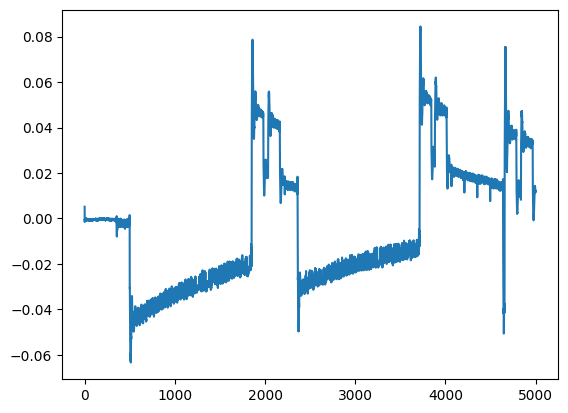

In [4]:
plt.plot(Xh_downsampled[0])

In [ ]:
model_json = open('../data/pretrained/unet_5000_101_structure.json', 'r')
model_json = model_json.read()
unet5 = model_from_json(model_json)
unet5.load_weights('../data/pretrained/unet_5000_101_weights.keras')


2026-02-10 23:51:05.831575: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-10 23:51:05.847166: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-10 23:51:05.847276: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-10 23:51:05.847625: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

 1/64 [..............................] - ETA: 0s

64/64 [==============================] - 3s 49ms/step
Mean fuzz ratio: 99.70
Std dev fuzz ratio: 0.29
Min fuzz ratio: 97.20
Max fuzz ratio: 100.00


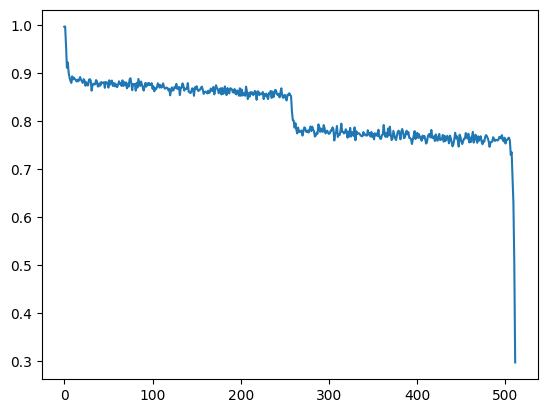

In [7]:
# Repeat the evaluation on the CM1 test data that was done in ctc_scaaml_data_train.ipynb
# This is mainly to check that the U-Net was loaded correctly

from Levenshtein import ratio as levenshtein_ratio

# Get actual sequence length from input shape
seq_length = X_downsampled.shape[1]  # Should be 5000
num_features = Y.shape[1]  # Number of features in Y

# Predict and decode with correct sequence length
Z_test = unet5.predict(X_downsampled, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * seq_length,  # Use 2000 instead of 1000
                             greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:num_features]
acc_test = np.mean(Z_test_decoded == Y, axis=0)
plt.plot(acc_test)

from fuzzywuzzy import fuzz

def binary_array_to_string(arr):
    return ''.join(map(str, arr.astype(int)))

# Calculate Levenshtein distances for each sample
distances = []
for i in range(len(Z_test_decoded)):
    pred_str = binary_array_to_string(Z_test_decoded[i])
    true_str = binary_array_to_string(Y[i])
    distance = levenshtein_ratio(pred_str, true_str) * 100
    distances.append(distance)

distances = np.array(distances)

print(f"Mean fuzz ratio: {np.mean(distances):.2f}")
print(f"Std dev fuzz ratio: {np.std(distances):.2f}")
print(f"Min fuzz ratio: {np.min(distances):.2f}")
print(f"Max fuzz ratio: {np.max(distances):.2f}")


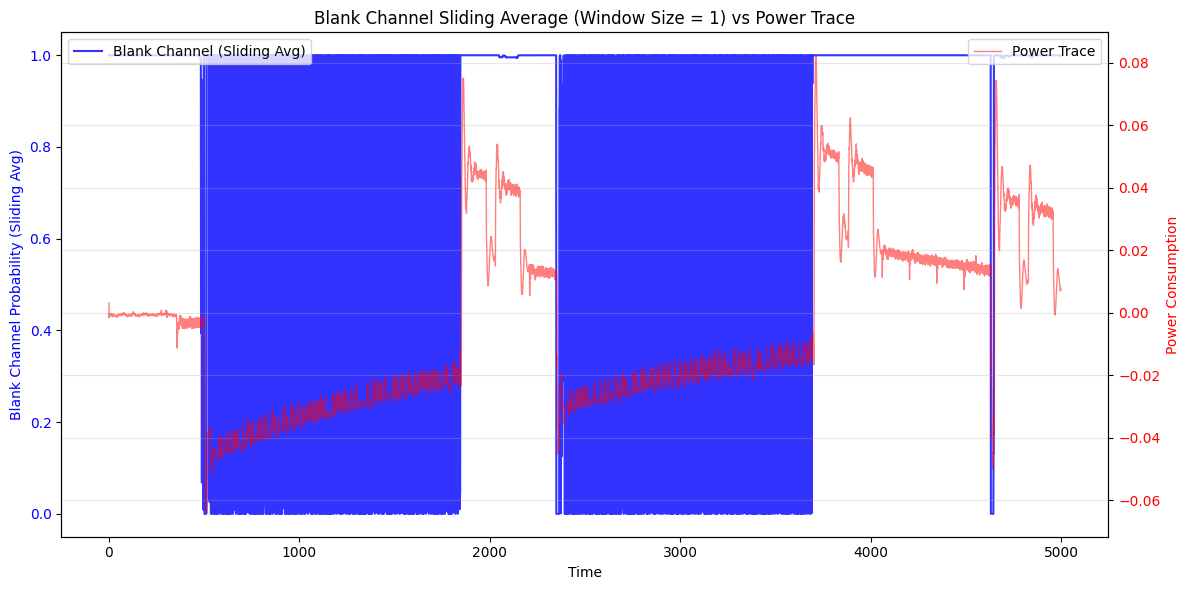

In [8]:
# Here, we see that the U-Net blank channel exactly tracks the active areas of the power trace
# The third active area is a bit of a mystery, but it seems plausible that there could be some
# leakage of the key from post-processing or maybe zeroizing of the key there.
# The implementation of both the crypto accelerator and the MCU driving it would be needed to
# definitively figure out what is happening there.

# We work with a sliding window average of the blank channel to make it easier to see what is happening
# but in the end opt to set the window size to 1, because seeing the blank channel jump between 0 and 1
# in the active regions turns out to show the active regions most clearly.

# Window size can easily be changed here

# Calculate sliding window average of the blank channel for the first test trace
def sliding_window_average(data, window_size):
    """Calculate sliding window average of a 1D array"""
    cumsum = np.cumsum(np.insert(data, 0, 0)) 
    return (cumsum[window_size:] - cumsum[:-window_size]) / window_size

# Extract the blank channel (index 2) from the first test trace predictions
blank_channel = Z_test[0, :, 2]

# Define window size for averaging
window_size = 1

# Calculate sliding window average
blank_avg = sliding_window_average(blank_channel, window_size)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot sliding window average of blank channel on first y-axis
ax1.plot(range(window_size//2, len(blank_avg) + window_size//2), blank_avg, 'b-', alpha=0.8, linewidth=1.5)
ax1.set_ylabel('Blank Channel Probability (Sliding Avg)', color='b')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='b')

# Create second y-axis and plot power trace
ax2 = ax1.twinx()
ax2.plot(X_downsampled[0], 'r-', alpha=0.5, linewidth=1)
ax2.set_ylabel('Power Consumption', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and adjust layout
plt.title('Blank Channel Sliding Average (Window Size = {}) vs Power Trace'.format(window_size))
plt.tight_layout()
plt.grid(True, alpha=0.3)

# Add legend
ax1.legend(['Blank Channel (Sliding Avg)'], loc='upper left')
ax2.legend(['Power Trace'], loc='upper right')

plt.show()

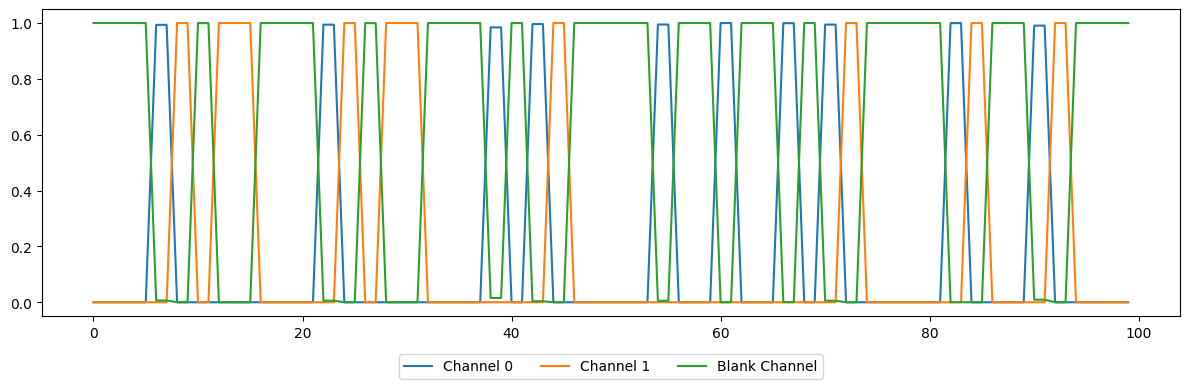

In [16]:
# now visualize all three channels (0,1,blank) for trace 0, indices 1000-1100
# this is right in the middle of the first active region

plt.figure(figsize=(12, 4))
plt.plot(Z_test[0, 1000:1100, 0])
plt.plot(Z_test[0, 1000:1100, 1])
plt.plot(Z_test[0, 1000:1100, 2])

# legend - placed below the plot in a horizontal layout
plt.legend(['Channel 0', 'Channel 1', 'Blank Channel'], loc='upper center', 
           bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.savefig('unet_channels_1000_1100.pdf', format='pdf', bbox_inches='tight')
plt.show()

# We see that there are large blank-gaps between clusters of four bits
# This suggests that the implementation processes the scalar in four-bit blocks
# Note that two consecutive non-blank symbols that are the same must be separated by a blank region due to CTC decoding
# This explains the small blank regions between consecutive bits

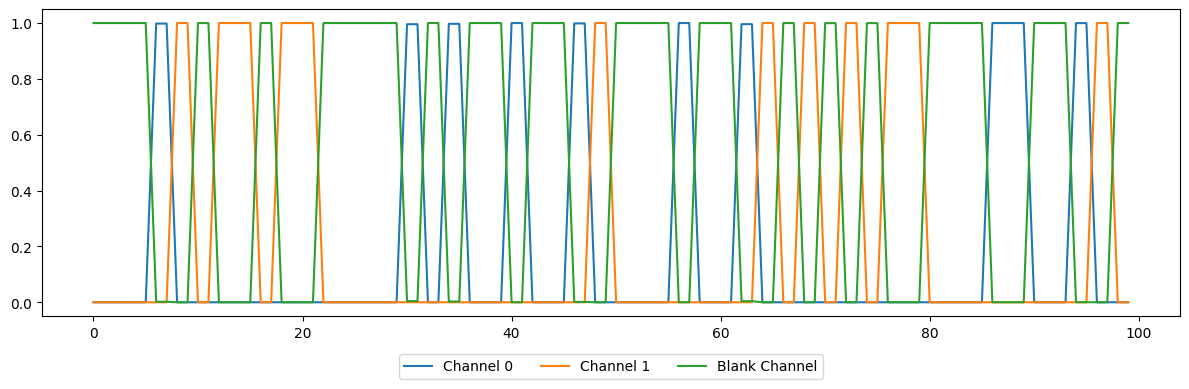

In [17]:
# Let's look at another spot, say indices 700-800

plt.figure(figsize=(12, 4))
plt.plot(Z_test[0, 700:800, 0])
plt.plot(Z_test[0, 700:800, 1])
plt.plot(Z_test[0, 700:800, 2])

# legend - placed below the plot in a horizontal layout
plt.legend(['Channel 0', 'Channel 1', 'Blank Channel'], loc='upper center', 
           bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.savefig('channels_700_800.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [52]:
# Get prediction and ground truth for trace 0

np.random.seed(42)
index = np.random.randint(0, len(Z_test_decoded))

print(f"Trace number: {index} in CM1 test data")

prediction = Z_test_decoded[index]
ground_truth = Y[index]

# Convert binary arrays to strings for easier comparison
pred_str = ''.join(map(str, prediction.astype(int)))
truth_str = ''.join(map(str, ground_truth.astype(int)))

# Print the first 100 bits of each for initial inspection
print("First 100 bits of prediction:", pred_str[:100])
print("First 100 bits of ground truth:", truth_str[:100])

# Function to find longest common subsequence
def lcs(X, Y):
    """Find the longest common subsequence between X and Y"""
    m, n = len(X), len(Y)
    
    # Create DP table
    L = [[0] * (n + 1) for _ in range(m + 1)]
    
    # Fill the DP table
    for i in range(m + 1):
        for j in range(n + 1):
            if i == 0 or j == 0:
                L[i][j] = 0
            elif X[i-1] == Y[j-1]:
                L[i][j] = L[i-1][j-1] + 1
            else:
                L[i][j] = max(L[i-1][j], L[i][j-1])
    
    # Backtrack to find the LCS and alignment
    i, j = m, n
    alignment = []
    
    while i > 0 and j > 0:
        if X[i-1] == Y[j-1]:
            # Match found
            alignment.append(('match', i-1, j-1, X[i-1], Y[j-1]))
            i -= 1
            j -= 1
        elif L[i-1][j] >= L[i][j-1]:
            # Deletion in prediction (or insertion in ground truth)
            alignment.append(('deletion', i-1, j, X[i-1], '-'))
            i -= 1
        else:
            # Insertion in prediction (or deletion in ground truth)
            alignment.append(('insertion', i, j-1, '-', Y[j-1]))
            j -= 1
    
    # Handle remaining characters
    while i > 0:
        alignment.append(('deletion', i-1, 0, X[i-1], '-'))
        i -= 1
    while j > 0:
        alignment.append(('insertion', 0, j-1, '-', Y[j-1]))
        j -= 1
    
    # Reverse the alignment to get correct order
    alignment.reverse()
    
    return alignment

# Get alignment using LCS
alignment = lcs(pred_str, truth_str)

# Filter out matches to focus only on differences
differences = [op for op in alignment if op[0] != 'match']

# Print alignment report in a readable format
print("\nLCS Alignment Report (differences only):")
print("Type         | Pred Pos | Truth Pos | Pred Bit | Truth Bit")
print("-------------|----------|-----------|----------|----------")

# Count different types of operations
match_count = len(alignment) - len(differences)
deletion_count = sum(1 for op in differences if op[0] == 'deletion')
insertion_count = sum(1 for op in differences if op[0] == 'insertion')

# Print first 20 differences for readability
for i, op in enumerate(differences[:20]):
    op_type, pred_pos, truth_pos, pred_bit, truth_bit = op
    print(f"{op_type:12} | {pred_pos:8d} | {truth_pos:9d} | {pred_bit:8} | {truth_bit:9}")

# Print summary statistics
total_ops = len(alignment)
print("\nAlignment Summary:")
print(f"Total operations: {total_ops}")
print(f"Matches: {match_count} ({match_count/total_ops*100:.2f}%)")
print(f"Differences: {len(differences)} ({len(differences)/total_ops*100:.2f}%)")
print(f"  - Deletions: {deletion_count} ({deletion_count/total_ops*100:.2f}%)")
print(f"  - Insertions: {insertion_count} ({insertion_count/total_ops*100:.2f}%)")

# Check if there's a consistent pattern at the beginning
first_ops = [op[0] for op in alignment[:10]]
print("\nFirst 10 operations:", first_ops)
if 'insertion' in first_ops[:3] or 'deletion' in first_ops[:3]:
    print("There appears to be an offset at the beginning of the sequences!")

# Analyze patterns in differences
if differences:
    # Check for consistent offset
    diff_positions = [(op[1], op[2]) for op in differences]
    position_diffs = [truth_pos - pred_pos for pred_pos, truth_pos in diff_positions]
    
    if len(set(position_diffs[:10])) == 1:
        print(f"\nConsistent offset detected: {position_diffs[0]} positions")
    
    # Check for periodic patterns
    intervals = [diff_positions[i+1][0] - diff_positions[i][0] for i in range(len(diff_positions)-1)]
    if intervals:
        most_common_interval = max(set(intervals[:20]), key=intervals[:20].count)
        interval_count = intervals[:20].count(most_common_interval)
        if interval_count > 5:  # Arbitrary threshold
            print(f"Possible periodic pattern detected: differences every {most_common_interval} positions")
    
    # Check for clusters of differences
    clusters = []
    current_cluster = [differences[0]]
    
    for i in range(1, len(differences)):
        if differences[i][1] - differences[i-1][1] <= 3:  # Arbitrary threshold for clustering
            current_cluster.append(differences[i])
        else:
            clusters.append(current_cluster)
            current_cluster = [differences[i]]
    
    if current_cluster:
        clusters.append(current_cluster)
    
    print(f"\nFound {len(clusters)} clusters of differences")
    print(f"Largest cluster size: {max(len(c) for c in clusters)}")
    print(f"First 3 cluster positions: {[c[0][1] for c in clusters[:3]]}")

Trace number: 1126 in CM1 test data
First 100 bits of prediction: 0100100001011000100000100011100001001110111010000101110111010010100000000011111100000100111110001111
First 100 bits of ground truth: 0100100001011000100000100011100001001110111010000101110111010010100000000011111100000100111110001111

LCS Alignment Report (differences only):
Type         | Pred Pos | Truth Pos | Pred Bit | Truth Bit
-------------|----------|-----------|----------|----------
insertion    |      497 |       497 | -        | 0        
insertion    |      497 |       498 | -        | 0        
deletion     |      510 |       512 | -        | -        
deletion     |      511 |       512 | 1        | -        
deletion     |      512 |       512 | -        | -        
deletion     |      513 |       512 | 1        | -        

Alignment Summary:
Total operations: 516
Matches: 510 (98.84%)
Differences: 6 (1.16%)
  - Deletions: 4 (0.78%)
  - Insertions: 2 (0.39%)

First 10 operations: ['match', 'match', 'match'

In [61]:
def analyze_transformed_traces(traces, labels, model, transform_params, rotation = 0,batch_size=32, max_length=256, plot=True):
    """
    Analyze traces after applying transformations by predicting labels and calculating fuzz ratio similarities.
    
    Args:
        traces: Input traces to transform and analyze
        labels: Ground truth labels to compare against
        model: Trained model for prediction
        transform_params: Dictionary specifying transformations to apply
        batch_size: Batch size for model prediction
        max_length: Maximum sequence length for predictions
        plot: Whether to plot histogram of similarities
        
    Returns:
        distances: Array of fuzz ratio similarity scores
        transformed_traces: The transformed input traces
    """
    # Transform traces
    transformed_traces = np.copy(traces)

    if rotation > 0:
        for i in range(transformed_traces.shape[0]):
            transformed_traces[i] = np.roll(transformed_traces[i], rotation)

    for i in range(transformed_traces.shape[0]):
        transformed_traces[i] = augment_trace(transformed_traces[i], transform_params)
    
    # Get predictions
    predictions = model.predict(transformed_traces, batch_size=batch_size)

    if rotation > 0:
        predictions = np.roll(predictions, -rotation, axis=1)

    # Use actual sequence length from input traces
    seq_length = transformed_traces.shape[1]
    decoded_preds = K.ctc_decode(predictions,
                                input_length=np.ones(predictions.shape[0]) * seq_length,
                                greedy=True)[0][0].numpy()
    decoded_preds = decoded_preds[:, 0:max_length]
    
    # Calculate similarities
    distances = []
    for i in range(len(decoded_preds)):
        pred_str = binary_array_to_string(decoded_preds[i])
        true_str = binary_array_to_string(labels[i])
        distance = fuzz.ratio(pred_str, true_str)
        distances.append(distance)
    distances = np.array(distances)
    
    # Optional plotting
    if plot:
        plt.hist(distances, bins=50)
        plt.title('Distribution of Fuzz Ratio Similarities for Augmented Traces')
        plt.xlabel('Similarity Score (0-100)')
        plt.ylabel('Count')
        
    return distances, transformed_traces

In [104]:
# No corruptions
no_corruptions = {
    "enabled_augmentations": []  # Empty list means no augmentations will be applied
}

# Modest corruption set
modest_corruptions = {
    "interrupts": {"num_interrupts": 5, "max_duration": 20},
    "jitter": {"jitter_strength": 1.0},  
    "power_management": {"num_changes": 2},
    "enabled_augmentations": ["interrupts", "jitter", "power_management"]
}

# Stronger corruption set
stronger_corruptions = {
    "noise": {"mean": 0, "std_dev": 0.00005},
    "interrupts": {"num_interrupts": 20, "max_duration": 20},
    "jitter": {"jitter_strength": 1.0},
    "power_management": {"num_changes": 5},
    "context_switch": {"num_switches": 4, "max_duration": 50},
    "frequency_change": {"num_changes": 3, "max_duration": 50, "max_slowdown": 1.5, "max_power_reduction": 0.6},
    "enabled_augmentations": ["noise", "interrupts", "time_warp", "power_management", 
                             "context_switch", "frequency_change"]
}

64/64 [==============================] - 3s 50ms/step


(array([ 99, 100, 100, ..., 100,  99, 100]),
 array([[ 3.13387997e-03, -1.55492977e-03, -3.81123944e-04, ...,
          7.63265369e-03,  6.95087248e-03,  7.93119427e-03],
        [ 3.78946774e-03, -1.31751585e-03,  2.48014549e-04, ...,
          1.03211394e-02,  8.67397059e-03,  9.15573630e-03],
        [ 4.80750576e-03, -9.00101033e-04,  3.31632997e-04, ...,
          1.03231994e-02,  9.82761662e-03,  1.10028749e-02],
        ...,
        [ 3.83980921e-03, -1.79105368e-03, -3.82915634e-04, ...,
          1.09117022e-02,  9.15023591e-03,  9.96520650e-03],
        [ 3.37115186e-03, -9.24028922e-04, -2.67314143e-04, ...,
          9.35853273e-03,  8.25988501e-03,  8.62613413e-03],
        [ 4.81579406e-03, -1.86894031e-03,  6.13012744e-05, ...,
          1.04529550e-02,  9.68774222e-03,  1.09569533e-02]]))

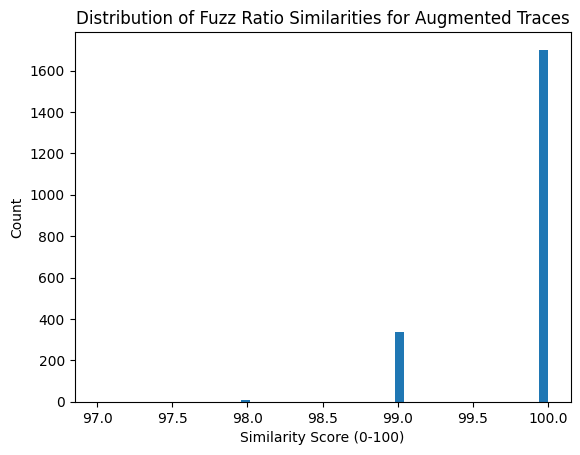

In [98]:
# Baseline: no corruptions

analyze_transformed_traces(X_downsampled, Y, unet5, no_corruptions, rotation = 0, batch_size=32, max_length=512, plot=True)

Random rotation: 860
64/64 [==============================] - 3s 50ms/step


(array([ 99, 100, 100, ...,  99, 100, 100]),
 array([[0.01767324, 0.0200089 , 0.01947057, ..., 0.01926581, 0.01942183,
         0.01905838],
        [0.01900854, 0.01937341, 0.01944279, ..., 0.01935365, 0.02057265,
         0.0180359 ],
        [0.01737087, 0.01927251, 0.01907097, ..., 0.01985365, 0.01897679,
         0.02028879],
        ...,
        [0.01950674, 0.01934855, 0.01916494, ..., 0.01976671, 0.01801868,
         0.01853115],
        [0.01992571, 0.01745708, 0.01981465, ..., 0.01766666, 0.02001685,
         0.01921715],
        [0.01900263, 0.01962952, 0.0178842 , ..., 0.02012021, 0.01744301,
         0.01930689]]))

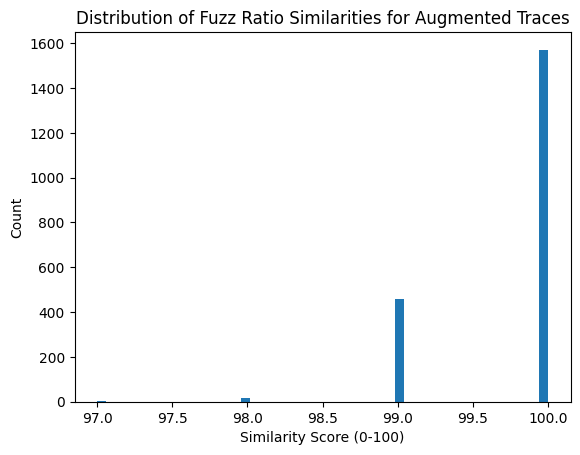

In [99]:
# no let's try a random rotation

np.random.seed(42)
rotation = np.random.randint(0, len(X_downsampled[0]))
print(f"Random rotation: {rotation}")
analyze_transformed_traces(X_downsampled, Y, unet5, no_corruptions, rotation = rotation, batch_size=32, max_length=512, plot=True)


64/64 [==============================] - 3s 50ms/step


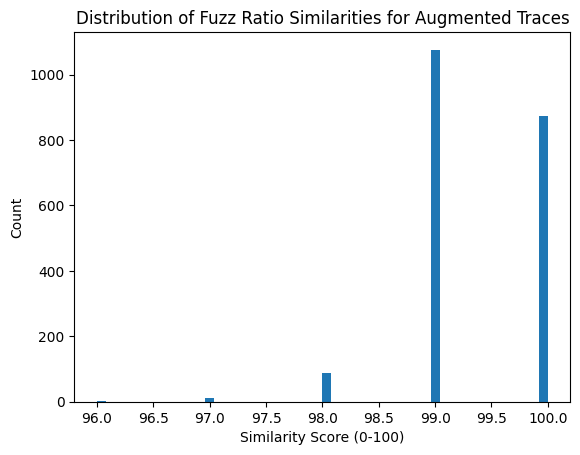

In [100]:
# now same with modest corruptions

_, transformed_traces = analyze_transformed_traces(X_downsampled, Y, unet5, modest_corruptions, rotation = 0, batch_size=32, max_length=512, plot=True)


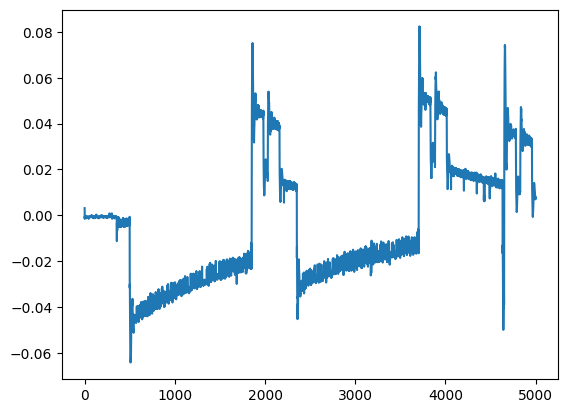

In [101]:
plt.plot(transformed_traces[0])
plt.show()

64/64 [==============================] - 3s 50ms/step


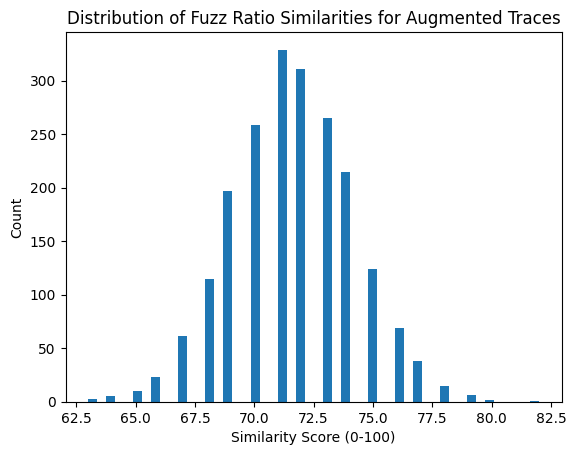

In [105]:
# now with stronger corruptions
# These are sufficient to overwhelm this model

_, transformed_traces = analyze_transformed_traces(X_downsampled, Y, unet5, stronger_corruptions, rotation = 0, batch_size=32, max_length=512, plot=True)



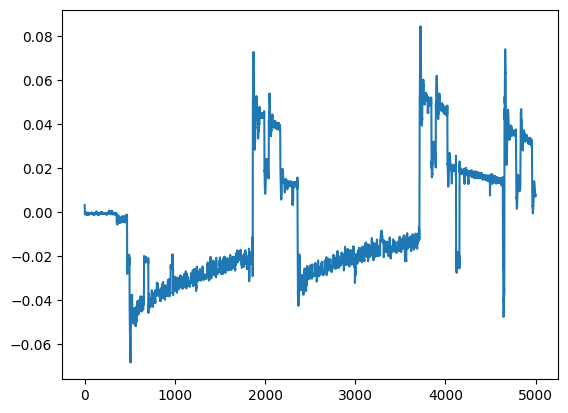

In [106]:
plt.plot(transformed_traces[0])

In [ ]:
# We will now try to use the same model to extract the first key share from the CM3 trace
# This is a cross-implementation attack!

data_cm3 = np.load('../data/cm3_test/cm3_data.npz')

In [10]:
X_cm3 = data_cm3['X']

print("X_cm3 shape:", X_cm3.shape)



X_cm3 shape: (8192, 20000)


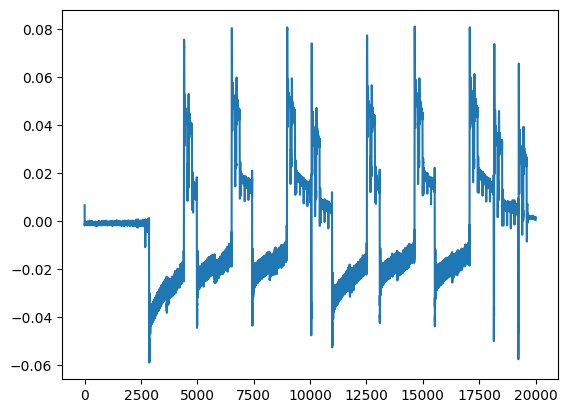

In [11]:
plt.plot(X_cm3[0])
plt.show()

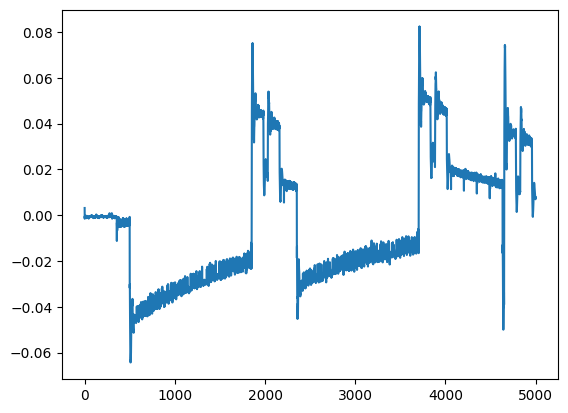

In [12]:
plt.plot(X_downsampled[0])

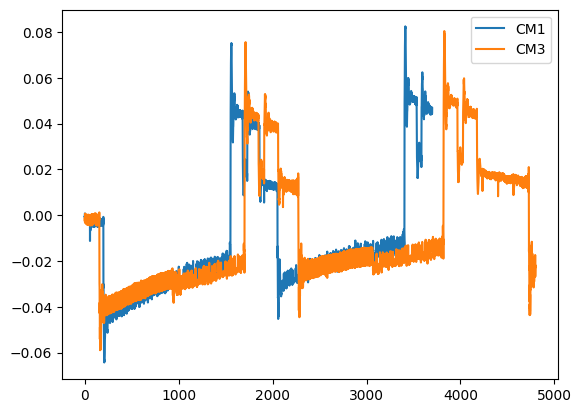

In [13]:
plt.plot(X_downsampled[0][300:4000])
plt.plot(X_cm3[0][2700:7500])
plt.legend(['CM1', 'CM3'])
plt.show()

In [14]:
print(np.argmax(X_downsampled[0][300:2500]))
print(np.argmax(X_cm3[0][2700:5000]))


1562
1713


In [15]:
20000/1713 * 1562

18237.01109165207

(5000,)


  0%|          | 0/8192 [00:00<?, ?it/s]

100%|██████████| 8192/8192 [00:01<00:00, 6004.55it/s]


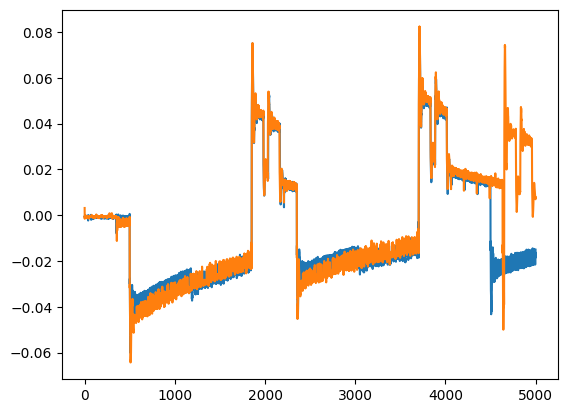

In [16]:
print(X_downsampled[0].shape)

resample_size = 17500

X_cm3_resample = resize_data(X_cm3, resample_size)
plt.plot(X_cm3_resample[0, 2000:7000])
plt.plot(X_downsampled[0])
plt.show()

In [17]:
# Let's look for comparison at the corresponding key share in the CM3 ground truth data

data_cm3.files

['X',
 'k',
 'k_bits',
 'r1',
 'r1_bits',
 'r2a',
 'r2a_bits',
 'r2b',
 'r2b_bits',
 'km1',
 'km1_bits',
 'km2a',
 'km2a_bits',
 'km2b',
 'km2b_bits',
 'rem2a',
 'rem2a_bits',
 'rem2b',
 'rem2b_bits']

In [18]:
k_bits = data_cm3['k_bits']
r1_bits = data_cm3['r1_bits']
r2a_bits = data_cm3['r2a_bits']
r2b_bits = data_cm3['r2b_bits']
km1_bits = data_cm3['km1_bits']
km2a_bits = data_cm3['km2a_bits']
km2b_bits = data_cm3['km2b_bits']
rem2a_bits = data_cm3['rem2a_bits']
rem2b_bits = data_cm3['rem2b_bits']


In [19]:
# Create a new UNet model with input layer resized to resample_size
# We rebuild using ml.unet_1d() which dynamically handles size mismatches
# in skip connections, then transfer weights from the original 5000-step model.

# Build a new UNet with the resample_size input, same architecture parameters as original
unet_resized = ml.unet_1d(resample_size, n_filters=64, depth=4,
                           output_size=resample_size, output_channels=3,
                           output_activation='softmax')

# Transfer weights from the original unet5 model layer by layer.
# Conv1D and BatchNorm weights are independent of input length, so they transfer directly.
# We match layers by iterating through layers with weights in order.
old_layers_with_weights = [l for l in unet5.layers if len(l.get_weights()) > 0]
new_layers_with_weights = [l for l in unet_resized.layers if len(l.get_weights()) > 0]

print(f"Original model: {len(old_layers_with_weights)} layers with weights")
print(f"New model: {len(new_layers_with_weights)} layers with weights")

# Transfer weights
transferred = 0
for old_layer, new_layer in zip(old_layers_with_weights, new_layers_with_weights):
    old_weights = old_layer.get_weights()
    new_weights = new_layer.get_weights()
    # Check shapes match
    if all(ow.shape == nw.shape for ow, nw in zip(old_weights, new_weights)):
        new_layer.set_weights(old_weights)
        transferred += 1
    else:
        print(f"  WARNING: Shape mismatch for {old_layer.name} -> {new_layer.name}")
        print(f"    Old: {[w.shape for w in old_weights]}")
        print(f"    New: {[w.shape for w in new_weights]}")

print(f"Transferred weights for {transferred}/{len(old_layers_with_weights)} layers")

print("\nModel created successfully with new input shape!")
print(f"Input shape: {unet_resized.input_shape}")

# Now predict on the full resample_size-step CM3 data
print(f"\nPredicting on full {resample_size}-step CM3 data...")
Z_cm3_full = unet_resized.predict(X_cm3_resample, batch_size=32)
print(f"Z_cm3_full shape: {Z_cm3_full.shape}")

# Decode with CTC using the full sequence length
Z_cm3_full_raw = K.ctc_decode(Z_cm3_full, 
                               input_length=np.ones(Z_cm3_full.shape[0]) * resample_size, 
                               greedy=True)[0][0].numpy()

print(f"Raw decoded shape: {Z_cm3_full_raw.shape}")

# CTC decode pads with -1 beyond the actual decoded sequence.
# Find the actual decoded length by looking for where -1 values start.
# We expect roughly 6 * 256 = 1536 decoded symbols for CM3.
decoded_lengths = np.argmax(Z_cm3_full_raw == -1, axis=1)
# If no -1 found (all decoded), argmax returns 0, so fix that
decoded_lengths[decoded_lengths == 0] = Z_cm3_full_raw.shape[1]
max_decoded_len = int(np.max(decoded_lengths))
print(f"Decoded lengths: min={np.min(decoded_lengths)}, max={max_decoded_len}, mean={np.mean(decoded_lengths):.1f}")

# Trim to the maximum actual decoded length
Z_cm3_full_decoded = Z_cm3_full_raw[:, :max_decoded_len]

print(f"Trimmed decoded shape: {Z_cm3_full_decoded.shape}")
print(f"\nFirst trace decoded output (first 128 bits):")
print(Z_cm3_full_decoded[0, 0:128])

Original model: 35 layers with weights
New model: 35 layers with weights
Transferred weights for 35/35 layers

Model created successfully with new input shape!
Input shape: (None, 17500, 1)

Predicting on full 17500-step CM3 data...
256/256 [==============================] - 45s 168ms/step
Z_cm3_full shape: (8192, 17500, 3)
Raw decoded shape: (8192, 17500)
Decoded lengths: min=1277, max=1536, mean=1439.6
Trimmed decoded shape: (8192, 1536)

First trace decoded output (first 128 bits):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


CM3 Key Shares (padded to 256 bits with leading zeros):
  km2a      : 256 bits (already 256 bits)
  rem2a     : 256 bits (already 256 bits)
  r2a       : 128 bits -> 256 bits (prepended 128 zeros)
  km2b      : 256 bits (already 256 bits)
  rem2b     : 256 bits (already 256 bits)
  r2b       : 128 bits -> 256 bits (prepended 128 zeros)

Testing 6 key shares
Key share names: ['km2a', 'rem2a', 'r2a', 'km2b', 'rem2b', 'r2b']
Reference trace index: 0
Reference prediction length: 1439 bits
Expected ground truth length: 6 x 256 = 1536 bits

Testing all 720 permutations...

BEST PERMUTATION FOUND
Similarity ratio (reference trace): 97%

Permutation order:
  Position 0: km2a
  Position 1: rem2a
  Position 2: r2a
  Position 3: km2b
  Position 4: rem2b
  Position 5: r2b

APPLYING BEST PERMUTATION TO ALL TRACES


100%|██████████| 8192/8192 [00:02<00:00, 3072.41it/s]



Overall Statistics Across All 8192 Traces:
  Mean similarity ratio: 96.61%
  Std dev: 2.05%
  Min: 91.00%
  Max: 100.00%


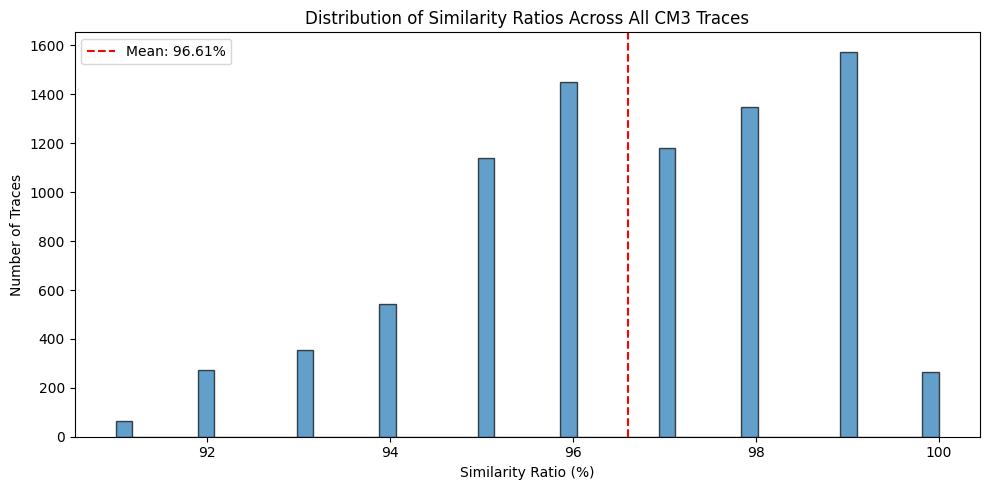

In [20]:
# Permutation-based assessment of predictions
# We test all 6! = 720 permutations to find which key shares correspond to which prediction segments

from itertools import permutations

# CM3 combines CM1 (additive masking) and CM2 (multiplicative masking):
# - CM1 splits k into r1 and km1 (both 256-bit)
# - CM2-style multiplicative masking is applied to BOTH r1 and km1:
#   * r1 is divided by r2a (128-bit) -> quotient km2a + remainder rem2a
#   * km1 is divided by r2b (128-bit) -> quotient km2b + remainder rem2b
# 
# The 6 scalar operations performed on chip are:
#   1. km2a × G
#   2. rem2a × G  
#   3. r2a × (km2a × G)  [point multiplication, but r2a goes through scalar mult loop]
#   4. km2b × G
#   5. rem2b × G
#   6. r2b × (km2b × G)  [point multiplication, but r2b goes through scalar mult loop]
#
# All 6 scalars are 128-bit values padded to 256 bits (high-order zeros) by the hardware

key_shares_raw = {
    'km2a': km2a_bits,      # 128 bits - quotient of r1/r2a
    'rem2a': rem2a_bits,    # 128 bits - remainder of r1/r2a
    'r2a': r2a_bits,        # 128 bits - mask for r1
    'km2b': km2b_bits,      # 128 bits - quotient of km1/r2b
    'rem2b': rem2b_bits,    # 128 bits - remainder of km1/r2b
    'r2b': r2b_bits,        # 128 bits - mask for km1
}

# Pad all key shares to 256 bits by prepending zeros (high-order bits)
# This matches what the hardware does
segment_size = 256
key_shares_dict = {}

print("CM3 Key Shares (padded to 256 bits with leading zeros):")
for name, shares in key_shares_raw.items():
    if shares.shape[1] < segment_size:
        # Prepend zeros to reach 256 bits (high-order zeros)
        padding = segment_size - shares.shape[1]
        key_shares_dict[name] = np.pad(shares, ((0, 0), (padding, 0)), 'constant')
        print(f"  {name:10s}: {shares.shape[1]:3d} bits -> {segment_size} bits (prepended {padding:3d} zeros)")
    else:
        key_shares_dict[name] = shares
        print(f"  {name:10s}: {shares.shape[1]:3d} bits (already 256 bits)")

key_share_names = list(key_shares_dict.keys())
num_shares = len(key_share_names)

print(f"\nTesting {num_shares} key shares")
print(f"Key share names: {key_share_names}")

# Choose a reference trace (first trace for reproducibility)
reference_idx = 0
reference_prediction = Z_cm3_full_decoded[reference_idx]
# Filter out any -1 padding values from the prediction
reference_prediction = reference_prediction[reference_prediction != -1]
pred_str_ref = binary_array_to_string(reference_prediction)

print(f"Reference trace index: {reference_idx}")
print(f"Reference prediction length: {len(reference_prediction)} bits")
print(f"Expected ground truth length: {num_shares} x {segment_size} = {num_shares * segment_size} bits")

# Test all 6! = 720 permutations
# For each permutation, concatenate the key shares in that order and compare
# the full prediction string to the full concatenated ground truth string
import math
best_similarity = 0
best_permutation = None

print(f"\nTesting all {math.factorial(num_shares)} permutations...")

for perm in permutations(range(num_shares)):
    # Concatenate key shares in this permutation order
    gt_concat = np.concatenate([key_shares_dict[key_share_names[i]][reference_idx] for i in perm])
    gt_str = binary_array_to_string(gt_concat)
    
    # Compare full prediction to full concatenated ground truth
    ratio = fuzz.ratio(pred_str_ref, gt_str)
    
    if ratio > best_similarity:
        best_similarity = ratio
        best_permutation = perm

# Print best permutation results
print(f"\n{'='*60}")
print(f"BEST PERMUTATION FOUND")
print(f"{'='*60}")
print(f"Similarity ratio (reference trace): {best_similarity}%")
print(f"\nPermutation order:")
for pos, share_idx in enumerate(best_permutation):
    print(f"  Position {pos}: {key_share_names[share_idx]}")

# Now apply this permutation to all traces and calculate mean similarity
print(f"\n{'='*60}")
print(f"APPLYING BEST PERMUTATION TO ALL TRACES")
print(f"{'='*60}")

all_similarities = []

for trace_idx in tqdm(range(len(Z_cm3_full_decoded))):
    # Get prediction and filter out -1 padding
    trace_pred = Z_cm3_full_decoded[trace_idx]
    trace_pred = trace_pred[trace_pred != -1]
    pred_str = binary_array_to_string(trace_pred)
    
    # Concatenate ground truth in best permutation order
    gt_concat = np.concatenate([key_shares_dict[key_share_names[i]][trace_idx] for i in best_permutation])
    gt_str = binary_array_to_string(gt_concat)
    
    ratio = fuzz.ratio(pred_str, gt_str)
    all_similarities.append(ratio)

all_similarities = np.array(all_similarities)

# Print statistics
print(f"\nOverall Statistics Across All {len(Z_cm3_full_decoded)} Traces:")
print(f"  Mean similarity ratio: {np.mean(all_similarities):.2f}%")
print(f"  Std dev: {np.std(all_similarities):.2f}%")
print(f"  Min: {np.min(all_similarities):.2f}%")
print(f"  Max: {np.max(all_similarities):.2f}%")

# Plot distribution of similarity ratios
plt.figure(figsize=(10, 5))
plt.hist(all_similarities, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(all_similarities), color='r', linestyle='--', linewidth=1.5, 
            label=f'Mean: {np.mean(all_similarities):.2f}%')
plt.xlabel('Similarity Ratio (%)')
plt.ylabel('Number of Traces')
plt.title('Distribution of Similarity Ratios Across All CM3 Traces')
plt.legend()
plt.tight_layout()
plt.show()

[0.73089484 0.75491481 0.78641411 0.74311927 0.78819672 0.74590701
 0.79593176 0.76377953 0.83224115 0.73691099 0.78127046 0.74295082
 0.77821522 0.73385519 0.73836066 0.78491803 0.74508519 0.79737705
 0.76408912 0.90429688 0.74458306 0.73346431 0.75343362 0.73890339
 0.72739187 0.74409449 0.72655738 0.77967213 0.78272251 0.75440888
 0.75408764 0.73154801 0.76094056 0.74523966 0.74064347 0.76258993
 0.78366013 0.7457405  0.75114604 0.72905759 0.78543307 0.73670387
 0.74720946 0.76062786 0.75458115 0.79619921 0.79095675 0.78688525
 0.73739358 0.74493133 0.74688525 0.82591623 0.74523966 0.73591088
 0.74117647 0.73756545 0.79698756 0.80130719 0.7434555  0.76651406
 0.78491803 0.74444444 0.73333333 0.72393443 0.73604728 0.75638507
 0.78781925 0.74263261 0.74362328 0.73918742 0.73856209 0.74558535
 0.74934555 0.72709424 0.79147541 0.7460733  0.7421466  0.78538813
 0.75801177 0.83104126 0.74672775 0.73542895 0.7252459  0.74377457
 0.78127046 0.79856115 0.75344262 0.73933027 0.79016393 0.7630

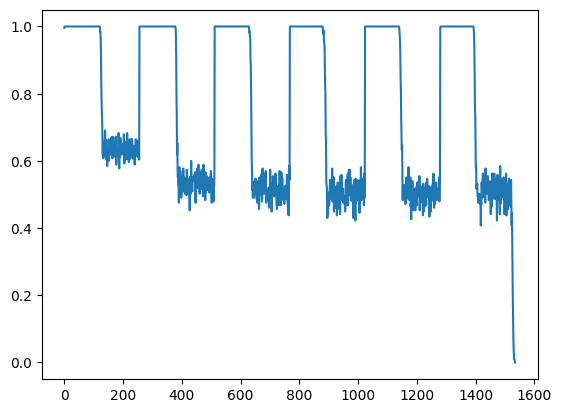

[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 

In [21]:
perfect_indices = np.where(all_similarities == 100)[0]

acc_perfect = np.zeros(len(perfect_indices))

acc_by_pos = np.zeros(6 * 256)

v_ratios = np.zeros(len(perfect_indices))

for i, idx in enumerate(perfect_indices):
    gt_concat = np.concatenate([key_shares_dict[key_share_names[i]][idx] for i in best_permutation])
    pred = Z_cm3_full_decoded[idx]
    pred = pred[pred != -1]
    pred_str = binary_array_to_string(pred)
    gt_str = binary_array_to_string(gt_concat)
    ratio = fuzz.ratio(pred_str, gt_str)
    v_ratios[i] = ratio
    min_len = min(len(pred), len(gt_concat))
    acc_perfect[i] = np.mean(pred[:min_len] == gt_concat[:min_len])
    acc_by_pos[:min_len] += (pred[:min_len] == gt_concat[:min_len])
acc_by_pos = acc_by_pos / len(perfect_indices)
print(acc_perfect)

plt.plot(acc_by_pos)
plt.show()

print(v_ratios)





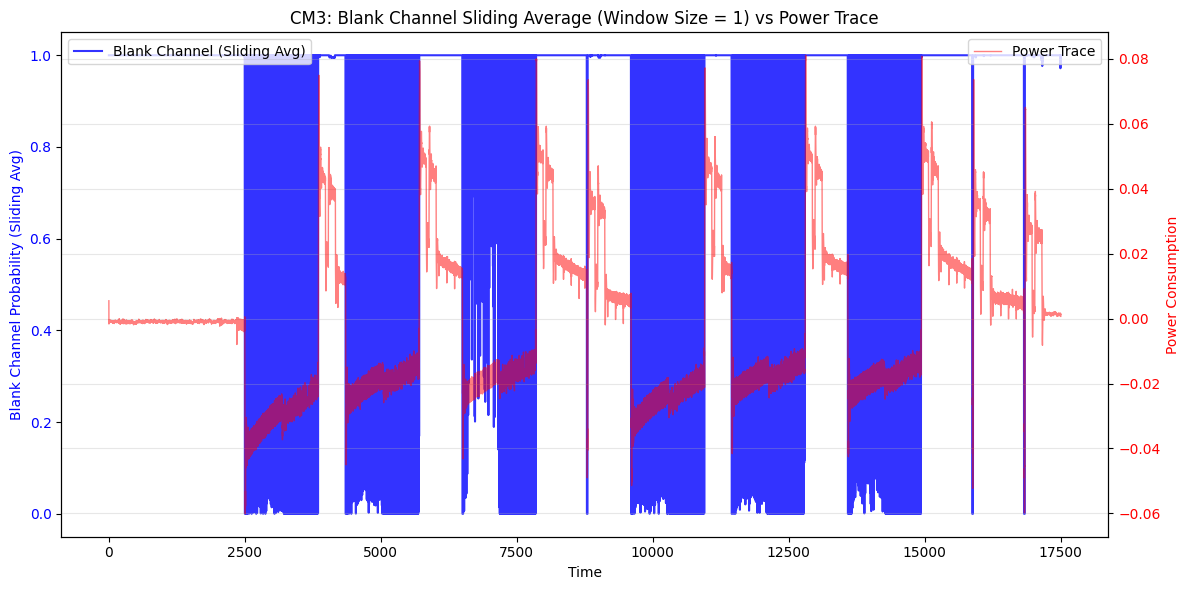

In [123]:
# CM3 trace overlaid with blank prediction (analogous to the CM1 plot in cell 6)

# Extract the blank channel (index 2) from the first CM3 trace predictions
blank_channel_cm3 = Z_cm3_full[0, :, 2]

# Define window size for averaging (1 = no averaging, shows raw blank channel)
window_size = 1

# Calculate sliding window average
blank_avg_cm3 = sliding_window_average(blank_channel_cm3, window_size)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot sliding window average of blank channel on first y-axis
ax1.plot(range(window_size//2, len(blank_avg_cm3) + window_size//2), blank_avg_cm3, 'b-', alpha=0.8, linewidth=1.5)
ax1.set_ylabel('Blank Channel Probability (Sliding Avg)', color='b')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='b')

# Create second y-axis and plot CM3 power trace
ax2 = ax1.twinx()
ax2.plot(X_cm3_resample[0], 'r-', alpha=0.5, linewidth=1)
ax2.set_ylabel('Power Consumption', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and adjust layout
plt.title('CM3: Blank Channel Sliding Average (Window Size = {}) vs Power Trace'.format(window_size))
plt.tight_layout()
plt.grid(True, alpha=0.3)

# Add legend
ax1.legend(['Blank Channel (Sliding Avg)'], loc='upper left')
ax2.legend(['Power Trace'], loc='upper right')

plt.show()

DIAGNOSTIC: Active region analysis for CM3 trace 0
Trace 0: found 9 active regions
  Region 0: timesteps [ 2498,  3846)  ->  254 decoded symbols  [KEPT]
  Region 1: timesteps [ 4350,  5704)  ->  253 decoded symbols  [KEPT]
  Region 2: timesteps [ 6498,  7852)  ->  170 decoded symbols  [KEPT]
  Region 3: timesteps [ 8786,  8800)  ->    1 decoded symbols  [SUPPRESSED]
  Region 4: timesteps [ 9598, 10946)  ->  255 decoded symbols  [KEPT]
  Region 5: timesteps [11448, 12794)  ->  255 decoded symbols  [KEPT]
  Region 6: timesteps [13584, 14930)  ->  249 decoded symbols  [KEPT]
  Region 7: timesteps [15870, 15886)  ->    1 decoded symbols  [SUPPRESSED]
  Region 8: timesteps [16822, 16838)  ->    1 decoded symbols  [SUPPRESSED]
  Total decoded symbols after filtering: 1436

Across all 8192 CM3 traces:
  Active regions per trace:   mean=9.6, min=9, max=15
  Kept regions per trace:     mean=5.6
  Suppressed regions/trace:   mean=4.0
  Decoded length after filter: mean=1378.6, min=1003, max=1533

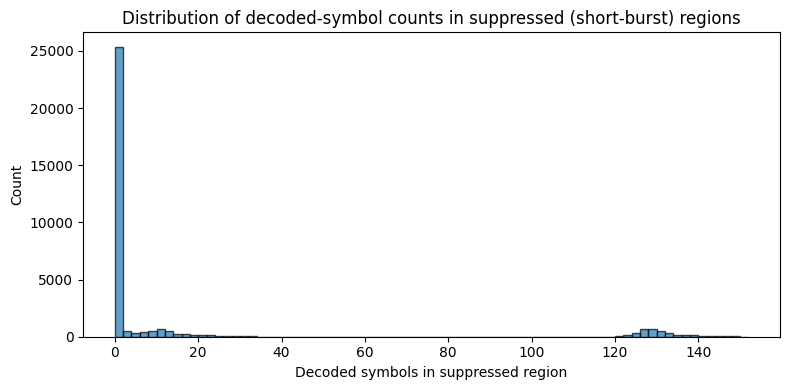

In [22]:
# Custom CTC decoding that suppresses short bursts of non-blank emissions.
#
# The standard greedy CTC decoder picks up all non-blank emissions, including short
# bursts that arise from non-target operations such as share recombination steps.
# In CM3 these recombination steps produce point additions that are indistinguishable 
# from the target point additions inside the scalar multiplications, so the U-Net emits 
# a short burst of non-blank symbols that get decoded as spurious key bits.
#
# The strategy: segment the per-timestep argmax sequence into "active regions" separated
# by long blank gaps (>= min_gap consecutive blanks). Then discard any active region
# whose greedy CTC decode yields fewer than min_region_symbols decoded symbols.

def ctc_decode_suppress_short_bursts(predictions, min_gap=100, min_region_symbols=150,
                                      blank_idx=2, verbose=False):
    """
    Greedy CTC decoding with short-burst suppression.
    
    Parameters
    ----------
    predictions : ndarray, shape (batch, time_steps, num_classes)
        Raw softmax output from the model.
    min_gap : int
        Minimum number of consecutive blank timesteps that separates two
        independent active regions.
    min_region_symbols : int
        Minimum number of decoded symbols an active region must produce to
        be retained.  Regions producing fewer symbols are suppressed.
    blank_idx : int
        Index of the CTC blank class in the output channels.
    verbose : bool
        If True, print diagnostic information for the first trace.
        
    Returns
    -------
    decoded_list : list of 1D int arrays
        One variable-length array of decoded symbols per trace.
    region_info : list of list of tuples
        Per-trace list of (start, end, num_decoded_symbols, kept) for each
        detected active region.  Useful for diagnostics.
    """
    batch_size, time_steps, num_classes = predictions.shape
    argmax_seq = np.argmax(predictions, axis=-1)       # (batch, time_steps)
    
    all_decoded = []
    all_region_info = []
    
    for b in range(batch_size):
        seq = argmax_seq[b]
        is_nonblank = (seq != blank_idx)
        
        # ---- Segment into active regions ----
        regions = []
        in_region = False
        region_start = 0
        consecutive_blanks = 0
        
        for t in range(time_steps):
            if is_nonblank[t]:
                if not in_region:
                    region_start = t
                    in_region = True
                consecutive_blanks = 0
            else:
                consecutive_blanks += 1
                if in_region and consecutive_blanks >= min_gap:
                    region_end = t - consecutive_blanks + 1
                    regions.append((region_start, region_end))
                    in_region = False
        
        # Close final region if still open
        if in_region:
            last_nonblank = time_steps - 1
            while last_nonblank > region_start and not is_nonblank[last_nonblank]:
                last_nonblank -= 1
            regions.append((region_start, last_nonblank + 1))
        
        # ---- Decode each region with standard CTC greedy collapse ----
        decoded_bits = []
        trace_region_info = []
        
        for start, end in regions:
            region_seq = seq[start:end]
            # CTC collapse: remove consecutive duplicates, then strip blanks
            collapsed = []
            prev = None
            for val in region_seq:
                if val != prev:
                    collapsed.append(val)
                prev = val
            collapsed = [v for v in collapsed if v != blank_idx]
            
            kept = len(collapsed) >= min_region_symbols
            trace_region_info.append((start, end, len(collapsed), kept))
            
            if kept:
                decoded_bits.extend(collapsed)
        
        if verbose and b == 0:
            print(f"Trace {b}: found {len(regions)} active regions")
            for i, (s, e, n, k) in enumerate(trace_region_info):
                tag = "KEPT" if k else "SUPPRESSED"
                print(f"  Region {i}: timesteps [{s:5d}, {e:5d})  "
                      f"-> {n:4d} decoded symbols  [{tag}]")
            print(f"  Total decoded symbols after filtering: {len(decoded_bits)}")
        
        all_decoded.append(np.array(decoded_bits, dtype=np.int32))
        all_region_info.append(trace_region_info)
    
    return all_decoded, all_region_info


# ---- Diagnostic run on the first trace with verbose output ----
print("=" * 70)
print("DIAGNOSTIC: Active region analysis for CM3 trace 0")
print("=" * 70)
decoded_custom, region_info = ctc_decode_suppress_short_bursts(
    Z_cm3_full, min_gap=100, min_region_symbols=150, blank_idx=2, verbose=True
)

# Summarise region statistics across all traces
num_regions_all   = [len(ri) for ri in region_info]
num_kept_all      = [sum(1 for _, _, _, k in ri if k) for ri in region_info]
num_suppressed_all = [sum(1 for _, _, _, k in ri if not k) for ri in region_info]
decoded_lengths   = [len(d) for d in decoded_custom]

print(f"\nAcross all {len(decoded_custom)} CM3 traces:")
print(f"  Active regions per trace:   mean={np.mean(num_regions_all):.1f}, "
      f"min={np.min(num_regions_all)}, max={np.max(num_regions_all)}")
print(f"  Kept regions per trace:     mean={np.mean(num_kept_all):.1f}")
print(f"  Suppressed regions/trace:   mean={np.mean(num_suppressed_all):.1f}")
print(f"  Decoded length after filter: mean={np.mean(decoded_lengths):.1f}, "
      f"min={np.min(decoded_lengths)}, max={np.max(decoded_lengths)}")

# Histogram of suppressed-region sizes (decoded symbols) to visualize the burst lengths
suppressed_sizes = [n for ri in region_info for (_, _, n, k) in ri if not k]
if suppressed_sizes:
    plt.figure(figsize=(8, 4))
    plt.hist(suppressed_sizes, bins=range(0, max(suppressed_sizes) + 5, 2),
             edgecolor='black', alpha=0.7)
    plt.xlabel('Decoded symbols in suppressed region')
    plt.ylabel('Count')
    plt.title('Distribution of decoded-symbol counts in suppressed (short-burst) regions')
    plt.tight_layout()
    plt.show()

Custom-decode similarity:   0%|          | 0/8192 [00:00<?, ?it/s]

Custom-decode similarity: 100%|██████████| 8192/8192 [00:02<00:00, 3147.66it/s]


COMPARISON: Standard greedy CTC  vs  Short-burst-suppressed CTC
Metric                             Standard   Suppressed      Delta
----------------------------------------------------------------------
Mean similarity (%)                   96.61        94.34     -2.26
Std dev (%)                            2.05         5.03 +     2.98
Min (%)                               91.00        79.00    -12.00
Max (%)                              100.00       100.00 +     0.00
Median (%)                            97.00        97.00 +     0.00


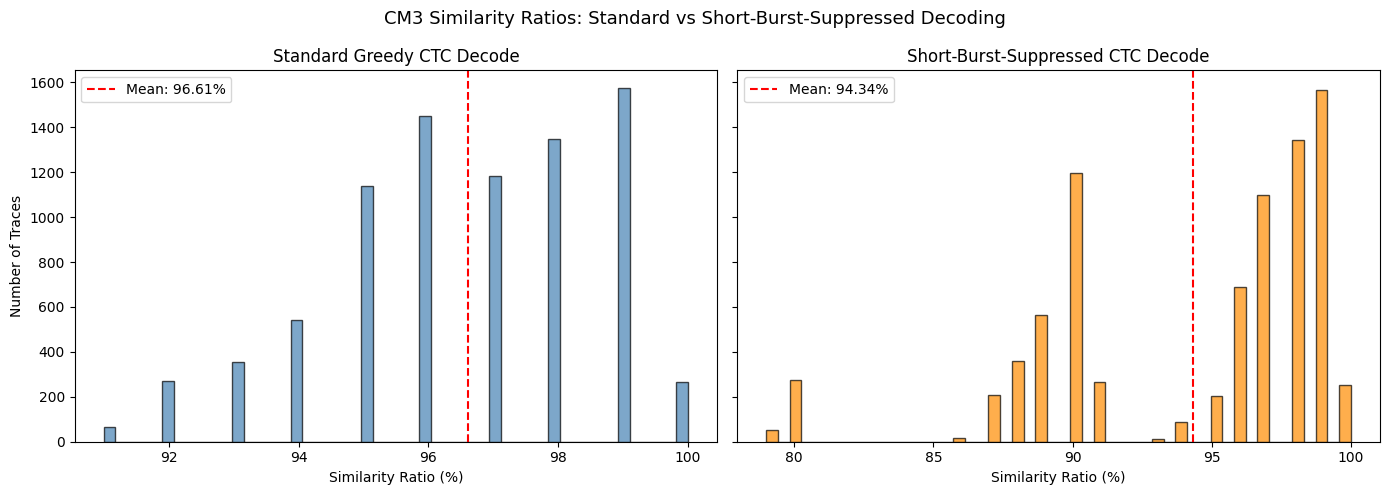


Per-trace improvement:
  Traces improved:  59 / 8192
  Traces unchanged: 5012 / 8192
  Traces worsened:  3121 / 8192
  Mean improvement: -2.26 pp


In [23]:
# Recompute CM3 similarity ratios using the custom CTC decoder (with short-burst suppression)
# and compare against the original greedy CTC decode result.
#
# We reuse the best_permutation found in the earlier cell so that both evaluations are
# on the same ground-truth ordering.

all_similarities_custom = []

for trace_idx in tqdm(range(len(decoded_custom)), desc="Custom-decode similarity"):
    # Get custom-decoded prediction (already a 1D array of bits, no -1 padding)
    trace_pred = decoded_custom[trace_idx]
    pred_str = binary_array_to_string(trace_pred)
    
    # Concatenate ground truth in best permutation order
    gt_concat = np.concatenate(
        [key_shares_dict[key_share_names[i]][trace_idx] for i in best_permutation]
    )
    gt_str = binary_array_to_string(gt_concat)
    
    ratio = fuzz.ratio(pred_str, gt_str)
    all_similarities_custom.append(ratio)

all_similarities_custom = np.array(all_similarities_custom)

# ---- Side-by-side comparison ----
print("=" * 70)
print("COMPARISON: Standard greedy CTC  vs  Short-burst-suppressed CTC")
print("=" * 70)
print(f"{'Metric':<30s} {'Standard':>12s} {'Suppressed':>12s} {'Delta':>10s}")
print("-" * 70)

metrics = [
    ("Mean similarity (%)",   np.mean(all_similarities),  np.mean(all_similarities_custom)),
    ("Std dev (%)",           np.std(all_similarities),   np.std(all_similarities_custom)),
    ("Min (%)",               np.min(all_similarities),   np.min(all_similarities_custom)),
    ("Max (%)",               np.max(all_similarities),   np.max(all_similarities_custom)),
    ("Median (%)",            np.median(all_similarities), np.median(all_similarities_custom)),
]

for name, old, new in metrics:
    delta = new - old
    sign = "+" if delta >= 0 else ""
    print(f"{name:<30s} {old:>12.2f} {new:>12.2f} {sign}{delta:>9.2f}")

# ---- Histograms ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(all_similarities, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(all_similarities), color='r', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(all_similarities):.2f}%')
axes[0].set_xlabel('Similarity Ratio (%)')
axes[0].set_ylabel('Number of Traces')
axes[0].set_title('Standard Greedy CTC Decode')
axes[0].legend()

axes[1].hist(all_similarities_custom, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(np.mean(all_similarities_custom), color='r', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(all_similarities_custom):.2f}%')
axes[1].set_xlabel('Similarity Ratio (%)')
axes[1].set_title('Short-Burst-Suppressed CTC Decode')
axes[1].legend()

plt.suptitle('CM3 Similarity Ratios: Standard vs Short-Burst-Suppressed Decoding', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Per-trace improvement ----
improvement = all_similarities_custom - all_similarities
print(f"\nPer-trace improvement:")
print(f"  Traces improved:  {np.sum(improvement > 0)} / {len(improvement)}")
print(f"  Traces unchanged: {np.sum(improvement == 0)} / {len(improvement)}")
print(f"  Traces worsened:  {np.sum(improvement < 0)} / {len(improvement)}")
print(f"  Mean improvement: {np.mean(improvement):+.2f} pp")

PER-REGION SIMILARITY MATRIX — Trace 0
  Region         Timesteps  #Syms      Status      km2a     rem2a       r2a      km2b     rem2b       r2b   Best match
----------------------------------------------------------------------------------------------------------------------
       0  [  2498,  3846)    254        KEPT     100.0      90.0      89.0      89.0      89.0      90.0   km2a (100.0%)
       1  [  4350,  5704)    253        KEPT      90.0      99.0      90.0      90.0      90.0      90.0   rem2a (99.0%)
       2  [  6498,  7852)    170        KEPT      67.0      68.0      80.0      68.0      69.0      69.0   r2a (80.0%)
       3  [  8786,  8800)      1       SUPPR       1.0       1.0       1.0       1.0       1.0       1.0   km2a (1.0%)
       4  [  9598, 10946)    255        KEPT      89.0      90.0      90.0     100.0      91.0      90.0   km2b (100.0%)
       5  [ 11448, 12794)    255        KEPT      89.0      90.0      90.0      90.0     100.0      89.0   rem2b (100.0%)


Per-region similarity: 100%|██████████| 8192/8192 [00:04<00:00, 1882.11it/s]



Traces with exactly 6 kept regions: 5254 / 8192

  Position   Key share    Mean %     Std %     Min %     Max %
-----------------------------------------------------------------
         0        km2a     99.90      0.30      98.0     100.0
         1       rem2a     99.63      0.49      98.0     100.0
         2         r2a     93.59      6.42      73.0     100.0
         3        km2b     99.74      0.44      98.0     100.0
         4       rem2b     99.34      0.52      97.0     100.0
         5         r2b     93.53      6.53      73.0     100.0

  Overall mean (all positions): 97.62%


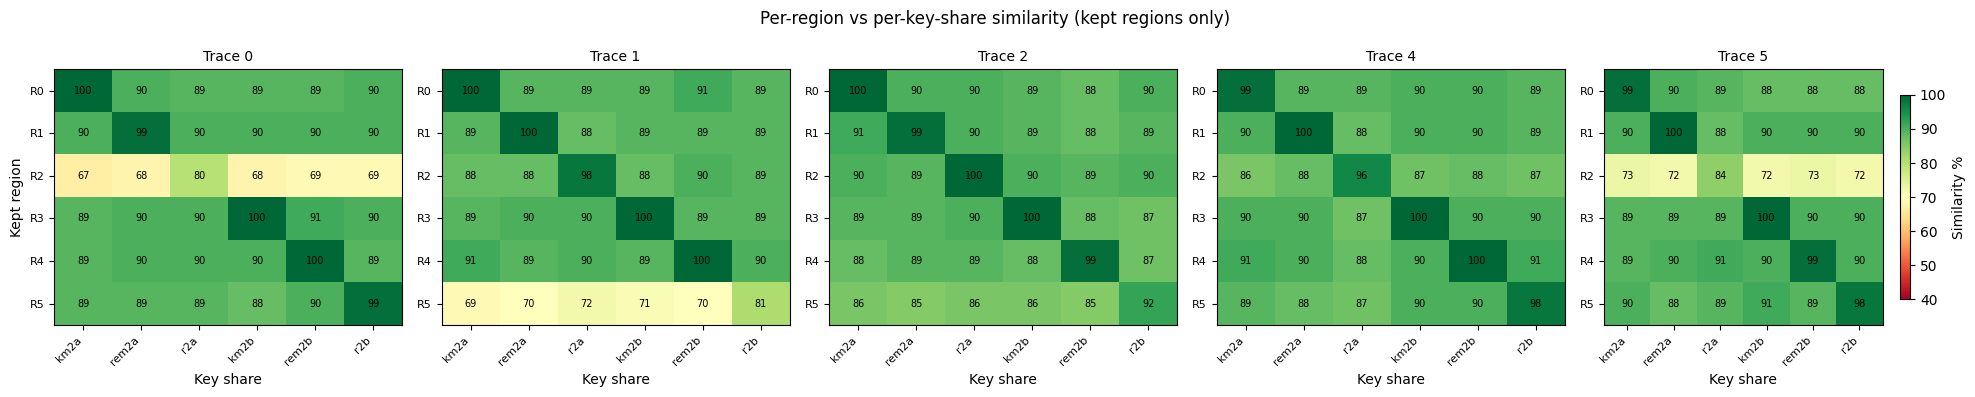

In [24]:
# Per-region similarity analysis: decode each active region independently and compare
# it to each key share in the best-permutation order.
#
# This reveals (a) which region maps to which key share, and (b) how the suppressed
# recombination bursts score against all key shares.

def decode_single_region(argmax_seq, start, end, blank_idx=2):
    """Standard CTC greedy collapse for a single region slice."""
    region_seq = argmax_seq[start:end]
    collapsed = []
    prev = None
    for val in region_seq:
        if val != prev:
            collapsed.append(int(val))
        prev = val
    collapsed = [v for v in collapsed if v != blank_idx]
    return np.array(collapsed, dtype=np.int32)


# Build the ordered ground-truth key shares list (following best_permutation)
ordered_share_names = [key_share_names[i] for i in best_permutation]
ordered_shares = [key_shares_dict[name] for name in ordered_share_names]
num_shares = len(ordered_shares)

argmax_all = np.argmax(Z_cm3_full, axis=-1)   # (8192, 17500)

# ---- Detailed analysis for trace 0 ----
trace_idx = 0
ri = region_info[trace_idx]
seq = argmax_all[trace_idx]

print("=" * 90)
print(f"PER-REGION SIMILARITY MATRIX — Trace {trace_idx}")
print("=" * 90)

# Header
header = f"{'Region':>8s}  {'Timesteps':>16s}  {'#Syms':>5s}  {'Status':>10s}"
for j in range(num_shares):
    header += f"  {ordered_share_names[j]:>8s}"
header += "   Best match"
print(header)
print("-" * len(header))

for i, (start, end, n_sym, kept) in enumerate(ri):
    bits = decode_single_region(seq, start, end)
    pred_str = binary_array_to_string(bits) if len(bits) > 0 else ""
    
    status = "KEPT" if kept else "SUPPR"
    row = f"{i:>8d}  [{start:>6d},{end:>6d})  {n_sym:>5d}  {status:>10s}"
    
    best_ratio = -1
    best_share = ""
    for j in range(num_shares):
        gt_str = binary_array_to_string(ordered_shares[j][trace_idx])
        ratio = fuzz.ratio(pred_str, gt_str) if len(pred_str) > 0 else 0
        row += f"  {ratio:>8.1f}"
        if ratio > best_ratio:
            best_ratio = ratio
            best_share = ordered_share_names[j]
    
    row += f"   {best_share} ({best_ratio:.1f}%)"
    print(row)

# ---- Aggregate across all traces: per-kept-region mean similarity to its positional share ----
# For traces that have exactly 6 kept regions (the most common case), compute the 
# similarity of the k-th kept region to the k-th key share.

print("\n" + "=" * 90)
print("AGGREGATE: Mean similarity of k-th kept region to k-th key share")
print("(restricted to traces with exactly 6 kept regions)")
print("=" * 90)

# Collect per-position similarity scores
per_pos_ratios = [[] for _ in range(num_shares)]
n_traces_used = 0

for trace_idx in tqdm(range(len(region_info)), desc="Per-region similarity"):
    ri = region_info[trace_idx]
    kept_regions = [(s, e, n, k) for (s, e, n, k) in ri if k]
    
    if len(kept_regions) != num_shares:
        continue   # skip traces where region count doesn't match share count
    
    n_traces_used += 1
    seq = argmax_all[trace_idx]
    
    for pos, (start, end, n_sym, _) in enumerate(kept_regions):
        bits = decode_single_region(seq, start, end)
        pred_str = binary_array_to_string(bits) if len(bits) > 0 else ""
        gt_str = binary_array_to_string(ordered_shares[pos][trace_idx])
        ratio = fuzz.ratio(pred_str, gt_str)
        per_pos_ratios[pos].append(ratio)

print(f"\nTraces with exactly {num_shares} kept regions: {n_traces_used} / {len(region_info)}")
print(f"\n{'Position':>10s}  {'Key share':>10s}  {'Mean %':>8s}  {'Std %':>8s}  {'Min %':>8s}  {'Max %':>8s}")
print("-" * 65)

for pos in range(num_shares):
    arr = np.array(per_pos_ratios[pos])
    print(f"{pos:>10d}  {ordered_share_names[pos]:>10s}  {np.mean(arr):>8.2f}  "
          f"{np.std(arr):>8.2f}  {np.min(arr):>8.1f}  {np.max(arr):>8.1f}")

# Overall mean across all positions
all_ratios_flat = np.concatenate([np.array(r) for r in per_pos_ratios])
print(f"\n  Overall mean (all positions): {np.mean(all_ratios_flat):.2f}%")

# ---- Heatmap for a handful of traces ----
n_show = min(5, n_traces_used)
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), squeeze=False)
shown = 0

for trace_idx in range(len(region_info)):
    if shown >= n_show:
        break
    ri = region_info[trace_idx]
    kept_regions = [(s, e, n, k) for (s, e, n, k) in ri if k]
    if len(kept_regions) != num_shares:
        continue
    
    seq = argmax_all[trace_idx]
    mat = np.zeros((len(kept_regions), num_shares))
    for i, (start, end, _, _) in enumerate(kept_regions):
        bits = decode_single_region(seq, start, end)
        pred_str = binary_array_to_string(bits) if len(bits) > 0 else ""
        for j in range(num_shares):
            gt_str = binary_array_to_string(ordered_shares[j][trace_idx])
            mat[i, j] = fuzz.ratio(pred_str, gt_str) if len(pred_str) > 0 else 0
    
    ax = axes[0, shown]
    im = ax.imshow(mat, cmap='RdYlGn', vmin=40, vmax=100, aspect='auto')
    ax.set_xticks(range(num_shares))
    ax.set_xticklabels(ordered_share_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(kept_regions)))
    ax.set_yticklabels([f"R{i}" for i in range(len(kept_regions))], fontsize=8)
    ax.set_title(f"Trace {trace_idx}", fontsize=10)
    ax.set_xlabel("Key share")
    if shown == 0:
        ax.set_ylabel("Kept region")
    
    # Annotate cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.0f}", ha='center', va='center', fontsize=7)
    
    shown += 1

fig.colorbar(im, ax=axes[0, -1], label='Similarity %', shrink=0.8)
plt.suptitle('Per-region vs per-key-share similarity (kept regions only)', fontsize=12)
plt.tight_layout()
plt.show()

Last-128 similarity:   0%|          | 0/8192 [00:00<?, ?it/s]

Last-128 similarity: 100%|██████████| 8192/8192 [00:05<00:00, 1584.87it/s]


Traces with exactly 6 kept regions: 5254 / 8192

PER-SHARE SIMILARITY: full region vs last-128-bits-zero-padded
 Pos     Share  GT bits  Full mean%  Full std%  Tail mean%  Tail std%    Delta
-----------------------------------------------------------------------------------------------
   0      km2a      127       99.76       0.20       99.58       0.31   -0.18
   1     rem2a      125       99.57       0.28       99.66       0.33  +  0.08
   2       r2a      128       93.57       6.39       99.23       0.49  +  5.65
   3      km2b      126       99.65       0.25       99.56       0.32   -0.09
   4     rem2b      128       99.36       0.35       99.24       0.52   -0.12
   5       r2b      128       93.52       6.51       99.13       0.54  +  5.61
-----------------------------------------------------------------------------------------------
       Overall                97.57       4.69       99.40       0.47  +  1.83


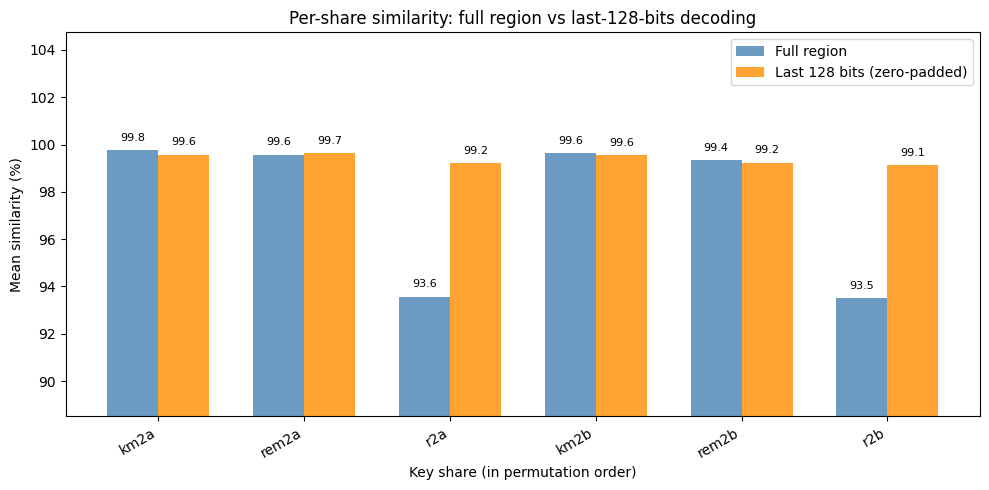

In [26]:
# Last-128-bit analysis: for every kept region, take only the last 128 decoded bits,
# pad with 128 leading zeros to form a 256-bit vector, and compare to the ground-truth
# key share at the same position.
#
# Rationale: r2a and r2b are 128-bit values zero-padded to 256 bits by the hardware.
# By uniformly keeping only the last 128 decoded bits for ALL shares, we test how well
# the model recovers the "information-carrying" portion of each scalar multiplication,
# factoring out the zero-prefix issue.

from Levenshtein import ratio as levenshtein_ratio

target_bits = 128   # keep this many bits from the tail of each region

per_pos_ratios_tail = [[] for _ in range(num_shares)]
per_pos_ratios_full = [[] for _ in range(num_shares)]   # full-region comparison for reference
n_traces_used_tail = 0

for trace_idx in tqdm(range(len(region_info)), desc="Last-128 similarity"):
    ri = region_info[trace_idx]
    kept_regions = [(s, e, n, k) for (s, e, n, k) in ri if k]
    
    if len(kept_regions) != num_shares:
        continue
    
    n_traces_used_tail += 1
    seq = argmax_all[trace_idx]
    
    for pos, (start, end, n_sym, _) in enumerate(kept_regions):
        bits = decode_single_region(seq, start, end)
        
        # --- last-128 + zero-pad to 256 ---
        if len(bits) >= target_bits:
            tail = bits[-target_bits:]
        else:
            tail = bits   # region shorter than 128 symbols; use what we have
        
        # Pad with leading zeros to 256 bits
        padded = np.zeros(256, dtype=np.int32)
        padded[256 - len(tail):] = tail
        
        pred_str_tail = binary_array_to_string(padded)
        gt_str = binary_array_to_string(ordered_shares[pos][trace_idx])
        
        ratio_tail = 100 * levenshtein_ratio(pred_str_tail, gt_str)
        per_pos_ratios_tail[pos].append(ratio_tail)
        
        # --- full region for comparison ---
        pred_str_full = binary_array_to_string(bits) if len(bits) > 0 else ""
        ratio_full = 100 * levenshtein_ratio(pred_str_full, gt_str)
        per_pos_ratios_full[pos].append(ratio_full)

print(f"Traces with exactly {num_shares} kept regions: {n_traces_used_tail} / {len(region_info)}")

# ---- Table ----
print("\n" + "=" * 95)
print(f"PER-SHARE SIMILARITY: full region vs last-{target_bits}-bits-zero-padded")
print("=" * 95)
print(f"{'Pos':>4s}  {'Share':>8s}  {'GT bits':>7s}  "
      f"{'Full mean%':>10s}  {'Full std%':>9s}  "
      f"{'Tail mean%':>10s}  {'Tail std%':>9s}  {'Delta':>7s}")
print("-" * 95)

for pos in range(num_shares):
    arr_full = np.array(per_pos_ratios_full[pos])
    arr_tail = np.array(per_pos_ratios_tail[pos])
    
    # How many non-zero ground-truth bits does this share actually have?
    # (to remind us which shares are truly 128-bit)
    sample_gt = ordered_shares[pos][0]
    first_nonzero = np.argmax(sample_gt != 0)  # first non-zero bit position
    effective_bits = 256 - first_nonzero if np.any(sample_gt != 0) else 0
    
    delta = np.mean(arr_tail) - np.mean(arr_full)
    sign = "+" if delta >= 0 else ""
    print(f"{pos:>4d}  {ordered_share_names[pos]:>8s}  {effective_bits:>7d}  "
          f"{np.mean(arr_full):>10.2f}  {np.std(arr_full):>9.2f}  "
          f"{np.mean(arr_tail):>10.2f}  {np.std(arr_tail):>9.2f}  "
          f"{sign}{delta:>6.2f}")

all_full = np.concatenate([np.array(r) for r in per_pos_ratios_full])
all_tail = np.concatenate([np.array(r) for r in per_pos_ratios_tail])
delta_all = np.mean(all_tail) - np.mean(all_full)
sign_all = "+" if delta_all >= 0 else ""
print("-" * 95)
print(f"{'':>4s}  {'Overall':>8s}  {'':>7s}  "
      f"{np.mean(all_full):>10.2f}  {np.std(all_full):>9.2f}  "
      f"{np.mean(all_tail):>10.2f}  {np.std(all_tail):>9.2f}  "
      f"{sign_all}{delta_all:>6.2f}")

# ---- Bar chart ----
x = np.arange(num_shares)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
means_full = [np.mean(per_pos_ratios_full[p]) for p in range(num_shares)]
means_tail = [np.mean(per_pos_ratios_tail[p]) for p in range(num_shares)]

bars1 = ax.bar(x - width/2, means_full, width, label='Full region', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, means_tail, width, label=f'Last {target_bits} bits (zero-padded)', 
               color='darkorange', alpha=0.8)

ax.set_ylabel('Mean similarity (%)')
ax.set_xlabel('Key share (in permutation order)')
ax.set_xticks(x)
ax.set_xticklabels(ordered_share_names, rotation=30, ha='right')
ax.set_ylim(bottom=min(min(means_full), min(means_tail)) - 5)
ax.legend()
ax.set_title(f'Per-share similarity: full region vs last-{target_bits}-bits decoding')

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cm3_last_128_bits_similarity.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [132]:
# Verify ground-truth bit patterns: are all shares effectively 128-bit?
# For each share, find the position of the first non-zero bit across all traces.

print("=" * 80)
print("GROUND TRUTH: Effective bit-widths of each key share")
print("=" * 80)

for name in ordered_share_names:
    shares = ordered_shares[ordered_share_names.index(name)]  # (8192, 256)
    
    # For each trace, find position of first non-zero bit (0-indexed from MSB)
    # If all zeros, first_nonzero = 256
    first_nonzero_per_trace = np.argmax(shares != 0, axis=1)
    # argmax returns 0 when no non-zero element exists OR when position 0 is non-zero
    # Fix: if shares[i,0]==0 and argmax==0, it means all zeros
    all_zero_mask = ~np.any(shares != 0, axis=1)
    first_nonzero_per_trace[all_zero_mask] = 256
    
    effective_bits = 256 - first_nonzero_per_trace
    
    # Also check: what is the highest bit position that is EVER non-zero?
    any_nonzero_per_col = np.any(shares != 0, axis=0)  # (256,)
    first_ever_nonzero = np.argmax(any_nonzero_per_col) if np.any(any_nonzero_per_col) else 256
    max_effective = 256 - first_ever_nonzero
    
    print(f"\n  {name}:")
    print(f"    Stored shape:         {shares.shape}")
    print(f"    Effective bits/trace:  mean={np.mean(effective_bits):.1f}, "
          f"min={np.min(effective_bits)}, max={np.max(effective_bits)}")
    print(f"    First non-zero col across ALL traces: bit position {first_ever_nonzero} "
          f"-> max effective width = {max_effective} bits")
    print(f"    Leading zero columns (always zero across all traces): {first_ever_nonzero}")
    
    # Show distribution of effective widths
    unique, counts = np.unique(effective_bits, return_counts=True)
    if len(unique) <= 10:
        for u, c in zip(unique, counts):
            print(f"      {u:>4d} effective bits: {c:>6d} traces ({100*c/len(shares):.1f}%)")
    else:
        print(f"      (wide distribution, showing summary only)")
        for pct in [0, 25, 50, 75, 100]:
            print(f"      {pct:>3d}th percentile: {np.percentile(effective_bits, pct):.0f} bits")

GROUND TRUTH: Effective bit-widths of each key share

  km2a:
    Stored shape:         (8192, 256)
    Effective bits/trace:  mean=128.4, min=115, max=142
    First non-zero col across ALL traces: bit position 114 -> max effective width = 142 bits
    Leading zero columns (always zero across all traces): 114
      (wide distribution, showing summary only)
        0th percentile: 115 bits
       25th percentile: 127 bits
       50th percentile: 128 bits
       75th percentile: 129 bits
      100th percentile: 142 bits

  rem2a:
    Stored shape:         (8192, 256)
    Effective bits/trace:  mean=125.6, min=112, max=128
    First non-zero col across ALL traces: bit position 128 -> max effective width = 128 bits
    Leading zero columns (always zero across all traces): 128
      (wide distribution, showing summary only)
        0th percentile: 112 bits
       25th percentile: 125 bits
       50th percentile: 126 bits
       75th percentile: 127 bits
      100th percentile: 128 bits

  r